## **Fixed Broadband Customer Churn Prediction**

Analisis ini digunakan sebagai bahan latihan dan membuat portfolio sebagai data scientist.

*~Ahmad Miftahul Farohi*

### **1. Problem Context**

PT ABC merupakan perusahaan yang bergerak di bidang IT dan telekomunikasi, dengan fokus pada layanan Fixed Broadband. Sebagai Data Scientist, tugas utama adalah menerjemahkan permasalahan bisnis menjadi solusi analitik yang dapat langsung dimanfaatkan oleh tim bisnis.

**Business Problem**
Perusahaan mengalami peningkatan kerugian akibat customer churn pada layanan Fixed Broadband. Tim bisnis ingin mengetahui pelanggan yang berpotensi melakukan churn dalam tiga bulan ke depan agar tim retention dapat mengambil tindakan proaktif untuk mempertahankan pelanggan.

**Skills yang Ditunjukkan**
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training & Hyperparameter Tuning
- Model Evaluation
- Business Insight & Stakeholder Communication

### **2. Dummy Dataset – Fixed Broadband Customers**

Dataset yang digunakan merupakan data sintetis (dummy) yang dibuat menggunakan Python dengan library NumPy dan Pandas untuk mensimulasikan karakteristik pelanggan layanan Fixed Broadband. Dataset terdiri dari **1.200** pelanggan, memiliki 11 fitur prediktor dan 1 target variable (churn), dengan tingkat churn sekitar 27% agar menyerupai kondisi bisnis yang realistis.

| Kolom              | Tipe Data       | Deskripsi                             | Nilai / Rentang                                     |
| ------------------ | --------------- | ------------------------------------- | --------------------------------------------------- |
| **customer_id**    | String          | Identitas unik pelanggan              | CUST0001 – CUST1200                                 |
| **region**         | Kategori        | Wilayah tempat pelanggan terdaftar    | Jakarta, Bandung, Surabaya, Medan, dan kota lainnya |
| **age_group**      | Kategori        | Kelompok usia pelanggan               | 18–25, 26–35, 36–45, 46–55, 55+                     |
| **tenure_months**  | Integer         | Lama berlangganan                     | 1–72 bulan                                          |
| **speed_mbps**     | Integer         | Kecepatan paket internet              | 10, 20, 50, 100, 150, 200, 300 Mbps                 |
| **monthly_charge** | Float           | Biaya langganan bulanan               | USD 15–180                                          |
| **contract_type**  | Kategori        | Jenis kontrak berlangganan            | Monthly, 6-Month, Annual                            |
| **support_calls**  | Integer         | Jumlah panggilan ke layanan pelanggan | 0–15 kali                                           |
| **downtime_hours** | Integer         | Total jam gangguan layanan            | 0–30 jam                                            |
| **autopay**        | Binary          | Status pembayaran otomatis            | 0 = Tidak, 1 = Ya                                   |
| **bundle_package** | Kategori        | Paket layanan yang digunakan          | Internet Only, Internet + TV, Internet + TV + Phone |
| **churn**          | Binary (Target) | Status pelanggan                      | 0 = Active, 1 = Churn                               |


In [1]:
import numpy as np 
import pandas as pd 

In [8]:
df = pd.read_csv('broadband_churn_data.csv')
df.shape 

(1200, 12)

In [9]:
df

,customer_id,region,age_group,tenure_months,speed_mbps,monthly_charge,contract_type,support_calls,downtime_hours,autopay,bundle_package,churn
0,CUST0001,Bandung,26-35,52,50,34.39,Annual,3,3,1,Internet Only,0
1,CUST0002,Jakarta,26-35,15,50,30.42,Monthly,14,18,1,Internet Only,1
2,CUST0003,Bandung,26-35,72,10,20.71,Annual,2,0,1,Internet+TV,0
3,CUST0004,Jakarta,26-35,61,50,34.66,6-Month,3,0,1,Internet+TV,0
4,CUST0005,Jakarta,46-55,21,100,54.38,6-Month,3,1,0,Internet+TV+Phone,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,CUST1196,Surabaya,26-35,62,10,25.54,Monthly,2,0,1,Internet+TV,0
1196,CUST1197,Surabaya,26-35,62,100,54.55,Monthly,7,2,1,Internet Only,0
1197,CUST1198,Jakarta,18-25,57,10,15.00,6-Month,15,2,0,Internet+TV+Phone,0
1198,CUST1199,Medan,18-25,16,200,92.79,6-Month,12,0,1,Internet Only,0


### **3. Exploratory Data Analysis (EDA)**

EDA bertujuan memahami distribusi data, pola churn, dan relasi antar fitur sebelum masuk ke pemodelan. Ini adalah tahap paling penting untuk memastikan model kita tidak asal-asalan.

In [12]:
# Cek struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     1200 non-null   object 
 1   region          1200 non-null   object 
 2   age_group       1200 non-null   object 
 3   tenure_months   1200 non-null   int64  
 4   speed_mbps      1200 non-null   int64  
 5   monthly_charge  1200 non-null   float64
 6   contract_type   1200 non-null   object 
 7   support_calls   1200 non-null   int64  
 8   downtime_hours  1200 non-null   int64  
 9   autopay         1200 non-null   int64  
 10  bundle_package  1200 non-null   object 
 11  churn           1200 non-null   int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 112.6+ KB


In [13]:
# Cek ringkasan statistik
df.describe()

,tenure_months,speed_mbps,monthly_charge,support_calls,downtime_hours,autopay,churn
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,35.768333,89.825000,51.933917,7.375833,2.535000,0.623333,0.244167
std,20.800927,73.791985,27.041130,4.519211,3.117992,0.484752,0.429771
min,1.000000,10.000000,15.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,20.000000,31.827500,3.750000,0.000000,0.000000,0.000000
50%,35.000000,100.000000,46.450000,7.000000,2.000000,1.000000,0.000000
75%,54.000000,100.000000,65.832500,11.000000,3.000000,1.000000,0.000000
max,72.000000,300.000000,145.370000,15.000000,26.000000,1.000000,1.000000


**Cek missing value, data duplikat, dan outlier**

In [14]:
# Cek missing value
df.isnull().sum()

customer_id       0
region            0
age_group         0
tenure_months     0
speed_mbps        0
monthly_charge    0
contract_type     0
support_calls     0
downtime_hours    0
autopay           0
bundle_package    0
churn             0
dtype: int64

In [15]:
# Cek duplikasi data
df.duplicated().sum()

np.int64(0)

In [27]:
# Cek Outlier dengan metode IQR
def count_outliers_iqr(df, columns):
    result = []

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        result.append({
            'Column': col,
            'Outliers': len(outliers),
            'Percentage (%)': round(len(outliers) / len(df) * 100, 2)
        })

    return pd.DataFrame(result)

In [28]:
# Cek outlier pada kolom numerik
numeric_cols = [
    'tenure_months',
    'speed_mbps',
    'monthly_charge',
    'support_calls',
    'downtime_hours'
]

count_outliers_iqr(df, numeric_cols)

,Column,Outliers,Percentage (%)
0,tenure_months,0,0.00
1,speed_mbps,64,5.33
2,monthly_charge,55,4.58
3,support_calls,0,0.00
4,downtime_hours,83,6.92


Outlier diidentifikasi menggunakan metode Interquartile Range (IQR). Hasilnya menunjukkan adanya outlier pada fitur speed_mbps (5,33%), monthly_charge (4,58%), dan downtime_hours (6,92%). Namun, seluruh nilai tersebut masih berada dalam rentang yang valid secara bisnis (misalnya paket internet premium atau durasi gangguan layanan yang tinggi), sehingga outlier dipertahankan dan tidak dilakukan penghapusan data sebelum proses pemodelan.

**Distribusi target**

In [29]:
# Cek distribusi churn keseluruhan data
df['churn'].value_counts()

churn
0    907
1    293
Name: count, dtype: int64

In [30]:
# Cek distribusi churn keseluruhan data dalam bentuk persentase
df['churn'].value_counts(normalize=True)

churn
0    0.755833
1    0.244167
Name: proportion, dtype: float64

Distribusi target menunjukkan bahwa dari 1.200 pelanggan, terdapat 907 pelanggan (75,58%) yang masih aktif dan 293 pelanggan (24,42%) yang mengalami churn. Distribusi ini menunjukkan bahwa kelas target masih relatif seimbang (sekitar rasio 3:1), sehingga dataset tetap layak digunakan untuk membangun model klasifikasi tanpa indikasi ketidakseimbangan kelas (class imbalance) yang ekstrem.

**Cek distribusi masing-masing variabel/kolom**

In [31]:
# Cek distribusi region
df['region'].value_counts()

region
Jakarta     408
Bandung     251
Surabaya    247
Medan       172
Makassar    122
Name: count, dtype: int64

Mayoritas pelanggan berasal dari wilayah Jakarta, sedangkan Makassar memiliki jumlah pelanggan paling sedikit. Perbedaan distribusi ini perlu diperhatikan saat menganalisis churn per wilayah agar tidak hanya dipengaruhi oleh banyaknya jumlah pelanggan.

In [32]:
# Cek distribusi contract type
df['contract_type'].value_counts()

contract_type
Monthly    559
Annual     342
6-Month    299
Name: count, dtype: int64

Sebagian besar pelanggan menggunakan kontrak bulanan (Monthly). Karena kelompok ini juga memiliki tingkat churn tertinggi, kontrak bulanan berpotensi menjadi faktor penting dalam prediksi churn.

In [22]:
# Cek distribusi bundle package
df['bundle_package'].value_counts()

bundle_package
Internet Only        595
Internet+TV          440
Internet+TV+Phone    165
Name: count, dtype: int64

Sebagian besar pelanggan hanya berlangganan layanan internet tanpa tambahan TV atau telepon. Analisis selanjutnya dapat melihat apakah pelanggan dengan layanan tambahan memiliki kecenderungan churn yang lebih rendah.

<Axes: >

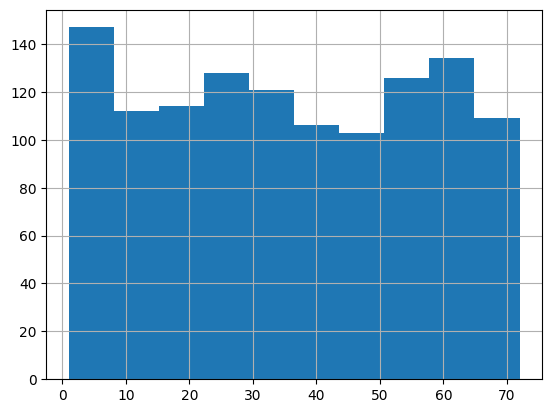

In [25]:
# Cek distribusi tenure_months
df['tenure_months'].hist()

Lama berlangganan pelanggan tersebar relatif merata pada rentang 1–72 bulan, sehingga model nantinya dapat mempelajari perilaku churn baik pada pelanggan baru maupun pelanggan lama.

<Axes: >

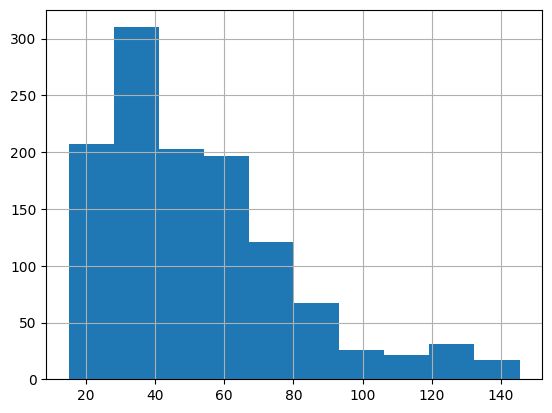

In [26]:
# Cek distribusi monthly_charge
df['monthly_charge'].hist()

Distribusi tagihan bulanan cenderung miring ke kanan (right-skewed), menunjukkan bahwa sebagian besar pelanggan menggunakan paket dengan biaya rendah hingga menengah, sedangkan pelanggan dengan biaya langganan tinggi jumlahnya lebih sedikit.

**Cek distribusi churn dengan beberapa kolom yang lain**

In [33]:
# Cek rata-rata churn berdasarkan contract type
df.groupby('contract_type')['churn'].mean()

contract_type
6-Month    0.183946
Annual     0.166667
Monthly    0.323792
Name: churn, dtype: float64

Pelanggan dengan kontrak Monthly memiliki tingkat churn paling tinggi, hampir dua kali lipat dibanding pelanggan dengan kontrak Annual. Hal ini menunjukkan bahwa pelanggan dengan kontrak jangka pendek cenderung lebih mudah berhenti berlangganan karena tidak memiliki komitmen kontrak yang panjang.

In [34]:
# Cek rata-rata churn berdasarkan autopay
df.groupby('autopay')['churn'].mean()

autopay
0    0.285398
1    0.219251
Name: churn, dtype: float64

Pelanggan yang tidak menggunakan Autopay memiliki tingkat churn yang lebih tinggi dibanding pelanggan yang menggunakan Autopay. Hal ini menunjukkan bahwa fitur pembayaran otomatis kemungkinan membantu meningkatkan loyalitas pelanggan.

In [35]:
# Cek rata-rata churn berdasarkan bundle package
df.groupby('bundle_package')['churn'].mean()

bundle_package
Internet Only        0.235294
Internet+TV          0.227273
Internet+TV+Phone    0.321212
Name: churn, dtype: float64

Pelanggan yang menggunakan paket Internet + TV + Phone memiliki tingkat churn tertinggi (32,12%). Hasil tersebut menunjukkan bahwa pelanggan dengan paket lengkap pada data sintetis memiliki risiko churn lebih tinggi.

In [36]:
# Cek rata-rata churn berdasarkan region
df.groupby('region')['churn'].mean()

region
Bandung     0.278884
Jakarta     0.218137
Makassar    0.270492
Medan       0.261628
Surabaya    0.226721
Name: churn, dtype: float64

Bandung memiliki tingkat churn tertinggi, sedangkan Jakarta memiliki tingkat churn terendah. Namun, selisih antarwilayah tidak terlalu besar, sehingga region kemungkinan bukan faktor utama dibandingkan kontrak atau Autopay.

**Cek distribusi antar kolom**

In [39]:
corr = df.corr(numeric_only=True)

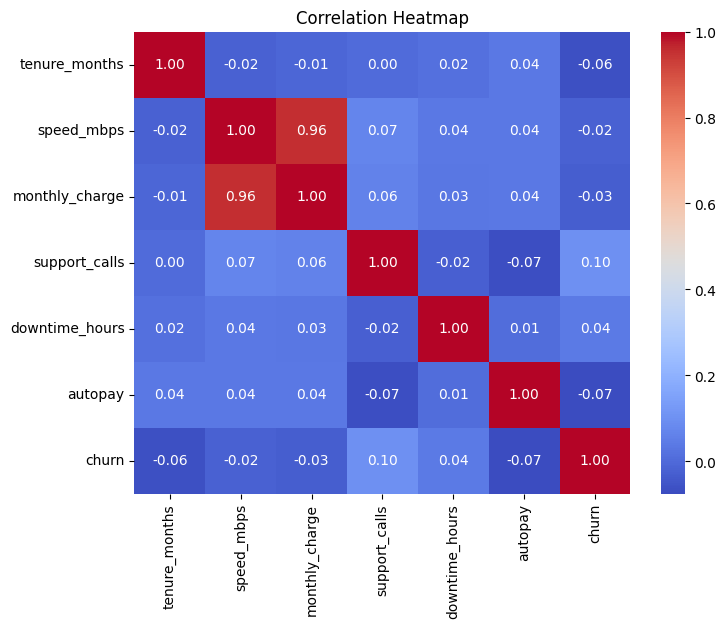

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

Hasil analisis korelasi menunjukkan bahwa speed_mbps dan monthly_charge memiliki korelasi positif yang sangat kuat (0,96), yang menunjukkan bahwa semakin tinggi kecepatan internet yang dipilih pelanggan, semakin besar biaya langganan bulanannya. 

Sementara itu, korelasi masing-masing fitur terhadap churn relatif rendah. Hal ini mengindikasikan bahwa perilaku churn tidak ditentukan oleh satu variabel saja, melainkan merupakan kombinasi dari beberapa faktor, sehingga penggunaan model machine learning seperti XGBoost lebih sesuai untuk menangkap hubungan yang lebih kompleks.

### **4. Feature Engineering**

Feature engineering adalah proses menciptakan atau mentransformasi fitur agar model dapat menangkap pola yang lebih kompleks.

**Encoding Fitur Kategorikal**

Sebelum dataset digunakan untuk melatih model machine learning, seluruh fitur yang bertipe kategorikal perlu diubah menjadi nilai numerik. Hal ini dilakukan karena sebagian besar algoritma machine learning hanya dapat memproses data dalam bentuk angka.

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['contract_type','bundle_package','region','age_group']:
    df[col] = le.fit_transform(df[col])

**Derived Features (Fitur Turunan)**

Untuk meningkatkan kemampuan model dalam menangkap pola churn, beberapa fitur turunan (derived features) dibuat dari fitur-fitur yang sudah ada. Fitur ini bertujuan merepresentasikan perilaku pelanggan secara lebih informatif dibanding menggunakan data mentah saja.

| Fitur Baru              | Formula                                | Tujuan                                                                                                                                                                    |
| ----------------------- | -------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **charge_per_mbps**     | `monthly_charge / speed_mbps`          | Mengukur biaya yang dibayar pelanggan untuk setiap Mbps, sehingga dapat merepresentasikan persepsi **value for money**.                                                   |
| **downtime_per_tenure** | `downtime_hours / (tenure_months + 1)` | Mengukur rata-rata gangguan layanan relatif terhadap lama pelanggan berlangganan, sehingga perbandingan menjadi lebih adil antara pelanggan baru dan lama.                |
| **support_per_tenure**  | `support_calls / (tenure_months + 1)`  | Mengukur intensitas pelanggan menghubungi customer service relatif terhadap masa berlangganan, sehingga mencerminkan tingkat keluhan pelanggan secara lebih proporsional. |


**Membuat fitur turunan**

In [45]:
df['charge_per_mbps'] = df['monthly_charge'] / df['speed_mbps']
df['downtime_per_tenure'] = df['downtime_hours'] / (df['tenure_months']+1)
df['support_per_tenure'] = df['support_calls'] / (df['tenure_months']+1)

In [46]:
df

,customer_id,region,age_group,tenure_months,speed_mbps,monthly_charge,contract_type,support_calls,downtime_hours,autopay,bundle_package,churn,charge_per_mbps,downtime_per_tenure,support_per_tenure
0,CUST0001,0,1,52,50,34.39,1,3,3,1,0,0,0.68780,0.056604,0.056604
1,CUST0002,1,1,15,50,30.42,2,14,18,1,0,1,0.60840,1.125000,0.875000
2,CUST0003,0,1,72,10,20.71,1,2,0,1,1,0,2.07100,0.000000,0.027397
3,CUST0004,1,1,61,50,34.66,0,3,0,1,1,0,0.69320,0.000000,0.048387
4,CUST0005,1,3,21,100,54.38,0,3,1,0,2,0,0.54380,0.045455,0.136364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,CUST1196,4,1,62,10,25.54,2,2,0,1,1,0,2.55400,0.000000,0.031746
1196,CUST1197,4,1,62,100,54.55,2,7,2,1,0,0,0.54550,0.031746,0.111111
1197,CUST1198,1,0,57,10,15.00,0,15,2,0,2,0,1.50000,0.034483,0.258621
1198,CUST1199,3,0,16,200,92.79,0,12,0,1,0,0,0.46395,0.000000,0.705882


**Data Splitting**

Sebelum membangun model machine learning, dataset dibagi menjadi data training dan data testing.
- Training Set digunakan untuk melatih model agar dapat mempelajari pola yang membedakan pelanggan yang churn dan tidak churn.
- Test Set digunakan untuk menguji performa model pada data yang belum pernah dilihat sebelumnya, sehingga hasil evaluasi lebih objektif.

In [48]:
features = [
    'region',
    'age_group',
    'tenure_months',
    'speed_mbps',
    'monthly_charge',
    'contract_type',
    'support_calls',
    'downtime_hours',
    'autopay',
    'bundle_package',
    'charge_per_mbps',
    'downtime_per_tenure',
    'support_per_tenure'
]


In [50]:
from sklearn.model_selection import train_test_split

X = df[features] # 13 fitur
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Penjelasan Parameter**

- X = df[features] → Memilih seluruh fitur yang akan digunakan sebagai input model (13 fitur).
- y = df['churn'] → Menentukan target yang ingin diprediksi, yaitu apakah pelanggan akan churn atau tidak.
- test_size=0.2 → Sebanyak 20% data digunakan sebagai data pengujian, sedangkan 80% sisanya digunakan untuk melatih model.
- random_state=42 → Mengunci proses pembagian data agar hasilnya selalu sama setiap kali kode dijalankan (reproducible).
- stratify=y → Menjaga proporsi pelanggan churn dan non-churn tetap seimbang pada data training maupun data testing.

### **5. Model Training & Hyperparameter Tuning**

Pada tahap ini, model prediksi churn dibangun menggunakan algoritma Extreme Gradient Boosting (XGBoost). Algoritma ini dipilih karena memiliki performa yang sangat baik pada data tabular serta mampu menangkap hubungan yang kompleks antar fitur, sehingga banyak digunakan untuk menyelesaikan permasalahan klasifikasi seperti prediksi customer churn.

**Mengapa Memilih XGBoost?**
- Performa tinggi pada data tabular, sehingga sangat cocok untuk kasus prediksi churn pelanggan.
- Mampu menangani hubungan non-linear antar fitur yang sering ditemukan pada data pelanggan.
- Dilengkapi regularisasi (L1 & L2) untuk membantu mengurangi risiko overfitting.
- Proses training cepat dan efisien, bahkan pada dataset berukuran besar.
- Menyediakan feature importance, sehingga memudahkan interpretasi faktor-faktor yang paling berpengaruh terhadap churn.
- Telah banyak digunakan di industri dan kompetisi machine learning, termasuk berbagai studi kasus customer churn.

**Implementasi Model**

In [53]:
import xgboost as xgb

model = xgb.XGBClassifier(n_estimators=150, # jumlah trees
                          max_depth=4, # kedalaman tree (cegah overfitting)
                          learning_rate=0.1, # step size shrinkage
                          subsample=0.8, # row sampling per tree
                          colsample_bytree=0.8, # feature sampling per tree
                          eval_metric="logloss",
                          random_state=42)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

**Tuning dengan GridSearchCV**

Untuk memperoleh kombinasi hyperparameter yang menghasilkan performa terbaik, dilakukan proses hyperparameter tuning menggunakan GridSearchCV dari library scikit-learn.

GridSearchCV akan mencoba seluruh kombinasi hyperparameter yang telah ditentukan, kemudian mengevaluasi setiap kombinasi menggunakan 5-Fold Cross Validation. Kombinasi dengan nilai evaluasi terbaik akan dipilih sebagai model akhir.

**Kenapa perlu Hyperparameter Tuning?**

Nilai hyperparameter sangat memengaruhi performa model. Jika nilainya terlalu kecil, model bisa kurang mampu mempelajari pola (underfitting). Sebaliknya, jika terlalu besar, model berisiko menghafal data training (overfitting).

Dengan menggunakan GridSearchCV, proses pencarian hyperparameter dilakukan secara sistematis sehingga model yang dipilih memiliki peluang memberikan performa yang lebih baik pada data baru dibandingkan jika menggunakan nilai default atau memilih parameter secara manual.

In [54]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': [3, 4, 5],
              'learning_rate': [0.05, 0.1, 0.2],
              'n_estimators': [100, 150, 200],}

grid_search = GridSearchCV(xgb.XGBClassifier(), 
                           param_grid,
                           cv=5, 
                           scoring='roc_auc', 
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


**Penjelasan Parameter**

| Parameter               | Fungsi                                                                                                                                                                     |
| ----------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **xgb.XGBClassifier()** | Model yang akan dicari kombinasi hyperparameter terbaiknya.                                                                                                                |
| **param_grid**          | Daftar kombinasi hyperparameter yang akan diuji.                                                                                                                           |
| **cv=5**                | Menggunakan **5-Fold Cross Validation**, yaitu data training dibagi menjadi lima bagian dan proses training–evaluasi dilakukan sebanyak lima kali agar hasil lebih stabil. |
| **scoring='roc_auc'**   | Menggunakan nilai **ROC-AUC** sebagai metrik evaluasi karena cocok untuk mengukur kemampuan model membedakan pelanggan churn dan non-churn.                                |
| **n_jobs=-1**           | Menggunakan seluruh inti prosesor (CPU) agar proses tuning berjalan lebih cepat.                                                                                           |


**Mengapa Menggunakan ROC-AUC?**

Dataset memiliki distribusi target yang tidak seimbang, yaitu sekitar 24,42% pelanggan churn dan 75,58% pelanggan aktif. Pada kondisi seperti ini, accuracy dapat memberikan gambaran performa yang menyesatkan.

Sebagai contoh, jika model selalu memprediksi seluruh pelanggan sebagai aktif, maka model tetap memperoleh accuracy sebesar 75,58%, meskipun gagal mendeteksi seluruh pelanggan yang benar-benar akan churn.

Sebaliknya, ROC-AUC mengukur kemampuan model dalam membedakan pelanggan yang berpotensi churn dan pelanggan yang tetap aktif pada berbagai nilai threshold. Oleh karena itu, metrik ini lebih sesuai digunakan untuk mengevaluasi model klasifikasi pada kasus customer churn.

**Hasil Hyperparameter Tuning**

Proses hyperparameter tuning dilakukan menggunakan GridSearchCV dengan 5-Fold Cross Validation dan metrik evaluasi ROC-AUC. Dari 27 kombinasi hyperparameter yang diuji, diperoleh kombinasi terbaik sebagai berikut:
| Hyperparameter    | Nilai Terbaik | Penjelasan                                                                                                                                   |
| ----------------- | ------------: | -------------------------------------------------------------------------------------------------------------------------------------------- |
| **learning_rate** |      **0.05** | Model belajar secara lebih bertahap sehingga dapat meningkatkan kemampuan generalisasi dan mengurangi risiko overfitting.                    |
| **max_depth**     |         **3** | Pohon keputusan dibuat lebih sederhana sehingga model tidak terlalu kompleks dan lebih tahan terhadap overfitting.                           |
| **n_estimators**  |       **100** | Sebanyak 100 decision tree sudah cukup untuk memberikan performa terbaik pada dataset ini tanpa menambah kompleksitas yang tidak diperlukan. |


### **6. Model Evaluation**

Setelah proses training selesai, performa model dievaluasi menggunakan data testing yang tidak pernah digunakan selama proses pelatihan. Evaluasi dilakukan menggunakan beberapa metrik klasifikasi, yaitu Accuracy, Precision, Recall, F1-Score, dan ROC-AUC untuk mengukur kemampuan model dalam memprediksi pelanggan yang berpotensi churn.

Karena tujuan utama proyek ini adalah mengidentifikasi pelanggan yang berisiko churn, metrik Recall dan ROC-AUC menjadi perhatian utama dibanding hanya melihat nilai Accuracy.

In [59]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Prediksi
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Classification Report
print(classification_report(y_test, y_pred))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83       181
           1       0.41      0.25      0.31        59

    accuracy                           0.72       240
   macro avg       0.59      0.57      0.57       240
weighted avg       0.69      0.72      0.70       240

ROC-AUC: 0.5809532727783501


| Metric                |     Nilai | Interpretasi                                                                                                                   |
| --------------------- | --------: | ------------------------------------------------------------------------------------------------------------------------------ |
| **Accuracy**          |   **72%** | Model memprediksi dengan benar sekitar 72% dari seluruh data testing.                                                          |
| **Precision (Churn)** |   **41%** | Dari seluruh pelanggan yang diprediksi akan churn, sekitar 41% benar-benar churn.                                              |
| **Recall (Churn)**    |   **25%** | Model hanya berhasil mendeteksi sekitar 25% pelanggan yang benar-benar churn.                                                  |
| **F1-Score (Churn)**  |  **0.31** | Menunjukkan keseimbangan antara precision dan recall masih relatif rendah.                                                     |
| **ROC-AUC**           | **0.581** | Kemampuan model membedakan pelanggan churn dan non-churn masih rendah, hanya sedikit lebih baik dibanding tebakan acak (0.50). |


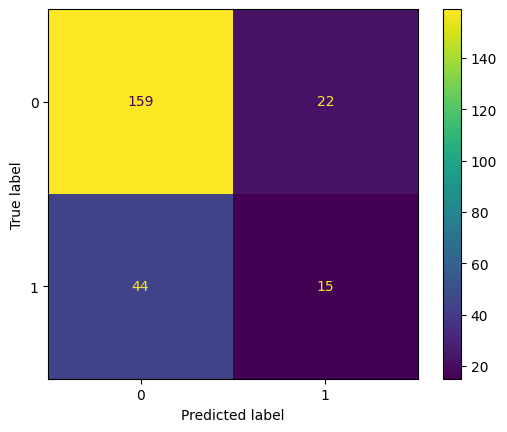

In [60]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

Model mampu mengidentifikasi sebagian besar pelanggan yang tetap aktif (159 dari 181 pelanggan aktif). Namun, kemampuan mendeteksi pelanggan yang akan churn masih terbatas. Dari 59 pelanggan yang benar-benar churn, model hanya berhasil mengidentifikasi 15 pelanggan, sedangkan 44 pelanggan churn tidak terdeteksi dan diprediksi sebagai pelanggan aktif.

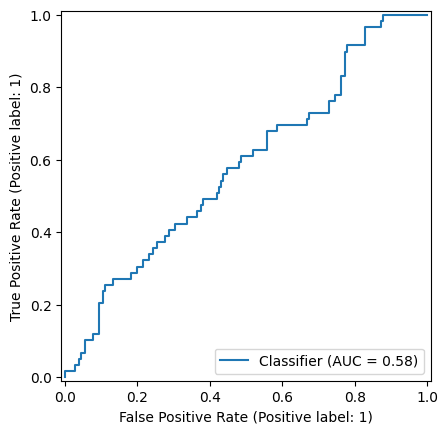

In [61]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()

Berdasarkan nilai ROC-AUC sebesar 0.58, model menunjukkan kemampuan yang masih terbatas dalam membedakan pelanggan churn dan non-churn. Hasil ini menjadi dasar untuk melakukan pengembangan lebih lanjut pada proses feature engineering, pemodelan, maupun kualitas data agar performa prediksi dapat ditingkatkan.

In [67]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
5,contract_type,0.131672
6,support_calls,0.083895
2,tenure_months,0.080534
0,region,0.079995
12,support_per_tenure,0.079775
9,bundle_package,0.077954
4,monthly_charge,0.076467
11,downtime_per_tenure,0.073967
7,downtime_hours,0.072211
10,charge_per_mbps,0.070474


**Insight**

Berdasarkan hasil feature importance dari model XGBoost, contract_type, support_calls, dan tenure_months merupakan tiga faktor yang paling berpengaruh dalam memprediksi churn pelanggan. 
- contract_type, tipe kontrak menjadi faktor yang paling berpengaruh dalam menentukan apakah seorang pelanggan berpotensi churn.
- support_calls, semakin sering pelanggan menghubungi customer service, semakin besar pengaruhnya terhadap prediksi churn.
- tenure_months, pelanggan dengan masa berlangganan yang lebih pendek umumnya memiliki risiko churn yang lebih tinggi dibanding pelanggan yang sudah lama menggunakan layanan.

Selain itu, fitur hasil feature engineering seperti support_per_tenure dan downtime_per_tenure juga memberikan kontribusi yang cukup besar terhadap model, menunjukkan bahwa informasi yang dinormalisasi berdasarkan lama berlangganan mampu membantu model mengenali pola churn dengan lebih baik.

### **7. Business Insight & Recommendation**

| **Insight**                                                                                                                         | **Business Implication**                                                                                                          | **Recommended Action**                                                                                                               |
| ----------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------ |
| **Pelanggan dengan kontrak Monthly memiliki churn rate tertinggi (32,38%) dibanding kontrak 6-Month (18,39%) dan Annual (16,67%).** | Pelanggan dengan kontrak jangka pendek memiliki komitmen yang lebih rendah sehingga lebih mudah berpindah ke kompetitor.          | Berikan promo upgrade ke kontrak 6 bulan atau Annual, misalnya potongan harga atau bonus satu bulan berlangganan.                    |
| **Frekuensi support calls merupakan salah satu fitur paling berpengaruh terhadap churn.**                                           | Pelanggan yang sering menghubungi customer service kemungkinan mengalami masalah layanan yang belum terselesaikan.                | Prioritaskan pelanggan dengan jumlah keluhan tinggi untuk mendapatkan penanganan lebih cepat (priority support).                     |
| **Pelanggan yang tidak menggunakan Autopay memiliki churn rate lebih tinggi dibanding pengguna Autopay.**                           | Proses pembayaran manual berpotensi menimbulkan hambatan atau keterlambatan pembayaran yang dapat meningkatkan risiko churn.      | Dorong adopsi Autopay melalui cashback, diskon tagihan, atau program loyalitas.                                                      |
| **Tenure menjadi salah satu faktor penting dalam model prediksi.**                                                                  | Pelanggan baru umumnya belum memiliki loyalitas yang kuat sehingga lebih berisiko berhenti berlangganan.                          | Tingkatkan kualitas onboarding dan lakukan follow-up pada pelanggan baru selama beberapa bulan pertama.                              |
| **Feature engineering seperti `support_per_tenure` dan `downtime_per_tenure` memberikan kontribusi terhadap model.**                | Intensitas keluhan dan gangguan layanan relatif terhadap lama berlangganan dapat menjadi indikator awal pelanggan berisiko churn. | Bangun dashboard monitoring untuk mendeteksi pelanggan berisiko tinggi sehingga tim retention dapat melakukan intervensi lebih awal. |


***Catatan:***

Model pada proyek ini berfungsi sebagai proof of concept (PoC) untuk menunjukkan proses end-to-end pembangunan model prediksi churn, mulai dari data preparation, exploratory data analysis, feature engineering, model development, hingga penyusunan rekomendasi bisnis. Pada implementasi di lingkungan produksi, performa model masih dapat ditingkatkan melalui penggunaan data yang lebih representatif, penambahan fitur yang relevan, serta optimasi model lebih lanjut.